# Spotify Music Analysis

## Project Overview

This project analyzes Spotify music data to explore patterns in song popularity, audio characteristics, artists, and genres.

The analysis focuses on identifying relationships between audio features and song popularity, as well as understanding the characteristics of music across different genres.

### Objectives

- Understand the Spotify music dataset
- Perform data cleaning and preprocessing
- Analyze the distribution of song popularity
- Identify popular artists and genres
- Analyze audio characteristics of songs
- Examine correlations between audio features and popularity
- Identify patterns associated with popular songs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "maharshipandya/-spotify-tracks-dataset"
)

print("Dataset location:")
print(path)

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Dataset location:
/kaggle/input/-spotify-tracks-dataset


In [ ]:
import os

print(os.listdir(path))

['dataset.csv']


In [ ]:
import glob

csv_files = glob.glob(path + "/*.csv")

print(csv_files)

['/kaggle/input/-spotify-tracks-dataset/dataset.csv']


In [ ]:
df = pd.read_csv(csv_files[0])

In [ ]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Data Understanding

This section examines the structure, data types, statistical characteristics, and completeness of the Spotify dataset before performing further analysis.

In [ ]:
df.shape

(114000, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
artists,1
album_name,1
track_name,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["track_id"].duplicated().sum()

np.int64(24259)

In [ ]:
print("Jumlah genre:", df["track_genre"].nunique())

Jumlah genre: 114


In [ ]:
df["track_genre"].value_counts().head(15)

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


In [ ]:
df["popularity"].describe()

,popularity
count,114000.000000
mean,33.238535
std,22.305078
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


In [ ]:
print("Minimum popularity:", df["popularity"].min())
print("Maximum popularity:", df["popularity"].max())
print("Average popularity:", df["popularity"].mean())

Minimum popularity: 0
Maximum popularity: 100
Average popularity: 33.2385350877193


## 3. Data Cleaning

The dataset is checked for missing values and duplicate records before conducting exploratory data analysis. Rows containing missing values in essential descriptive fields are removed to maintain data consistency.

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.shape

(113999, 21)

In [ ]:
print("Rows after cleaning:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())

Rows after cleaning: 113999
Columns: 21
Missing values: 0


## 4. Feature Engineering

A popularity category is created to group tracks into low, medium, and high popularity levels. This feature will be used to support categorical analysis of song popularity.

In [ ]:
def popularity_category(popularity):
    if popularity < 40:
        return "Low"
    elif popularity < 70:
        return "Medium"
    else:
        return "High"

In [ ]:
df["popularity_category"] = df["popularity"].apply(popularity_category)

In [ ]:
df[["popularity", "popularity_category"]].head()

,popularity,popularity_category
0,73,High
1,55,Medium
2,57,Medium
3,71,High
4,82,High


In [ ]:
df["popularity_category"].value_counts()

,count
popularity_category,
Low,65412
Medium,43115
High,5472


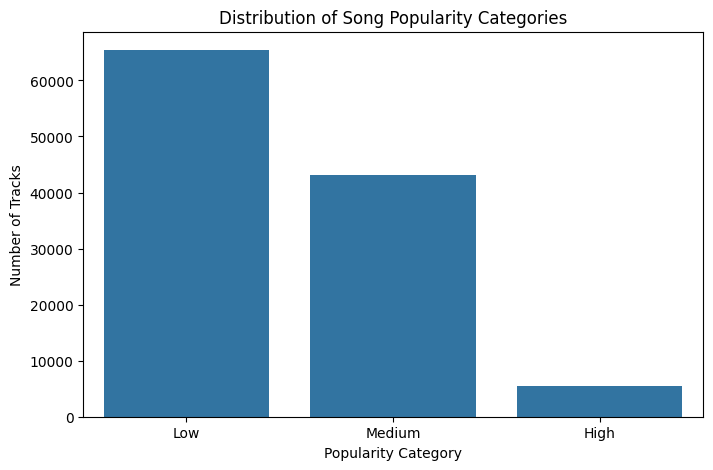

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="popularity_category",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Song Popularity Categories")
plt.xlabel("Popularity Category")
plt.ylabel("Number of Tracks")

plt.show()

## 5. Popularity Analysis

This section analyzes the distribution of song popularity and identifies the artists and genres associated with higher popularity levels.

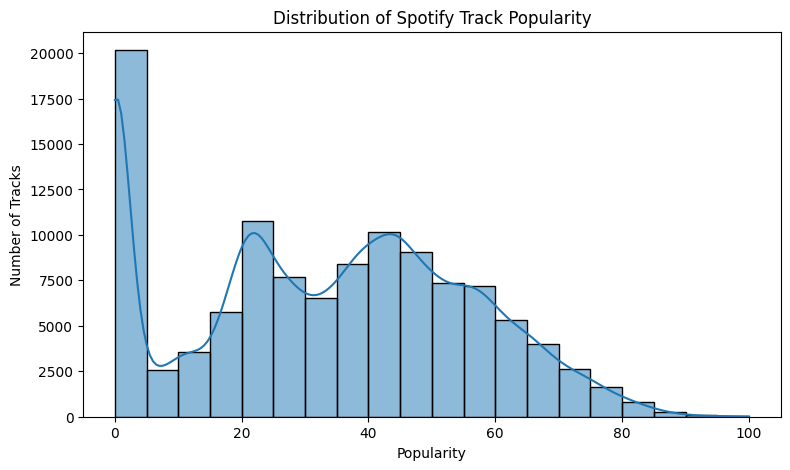

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="popularity",
    bins=20,
    kde=True
)

plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")

plt.show()

In [ ]:
top_tracks = (
    df[
        ["track_name", "artists", "track_genre", "popularity"]
    ]
    .sort_values("popularity", ascending=False)
    .head(10)
)

top_tracks

,track_name,artists,track_genre,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
88410,La Bachata,Manuel Turizo,reggae,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98
68303,La Bachata,Manuel Turizo,latino,98
89411,La Bachata,Manuel Turizo,reggaeton,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98
67356,La Bachata,Manuel Turizo,latin,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98


**Genre apa yang memiliki rata-rata popularity paling tinggi?**

In [ ]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

genre_popularity.head(10)

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
indian,49.539000
anime,48.772000
emo,48.128000
sertanejo,47.866000


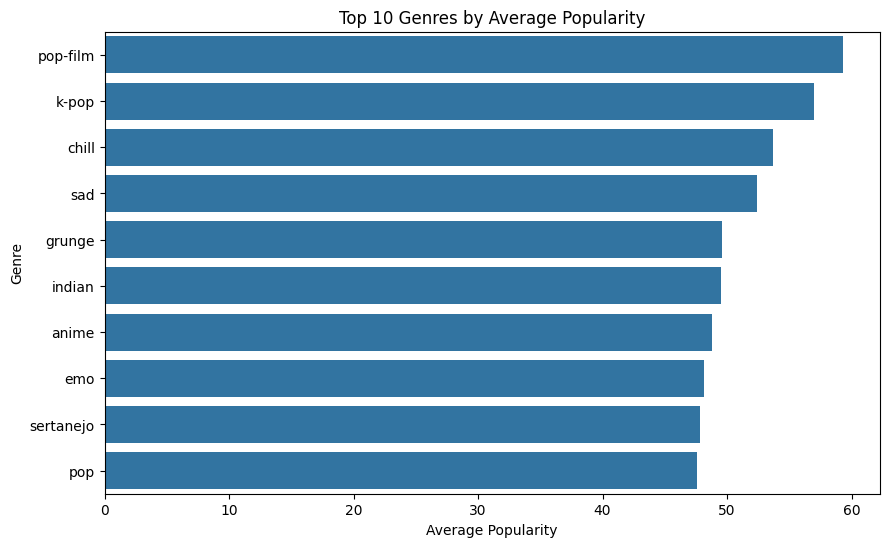

In [ ]:
top_genres = genre_popularity.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

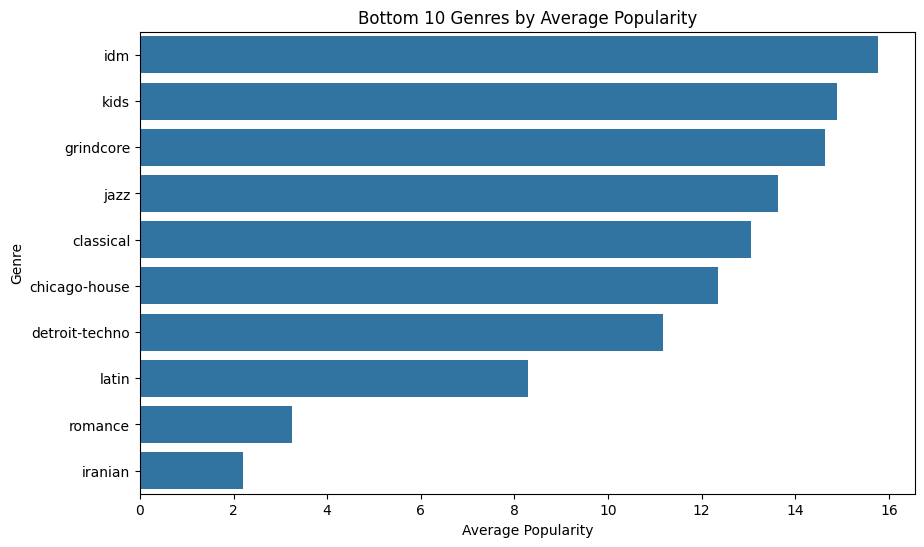

In [ ]:
bottom_genres = genre_popularity.tail(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=bottom_genres.values,
    y=bottom_genres.index
)

plt.title("Bottom 10 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

In [ ]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

df[audio_features].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,0.566801,0.641383,-8.258950,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695
std,0.173543,0.251530,5.029357,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500
50%,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,0.695000,0.854000,-5.003000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


In [ ]:
popularity_audio = (
    df.groupby("popularity_category")[audio_features]
    .mean()
)

popularity_audio

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity_category,,,,,,,,,
High,0.616051,0.671062,-6.663338,0.075320,0.221188,0.036544,0.171987,0.504489,120.133624
Low,0.557498,0.648751,-8.447244,0.091812,0.316515,0.180032,0.217576,0.486264,122.025060
Medium,0.574664,0.626439,-8.175788,0.074974,0.324361,0.134835,0.212728,0.451699,122.589370


In [ ]:
popularity_audio = popularity_audio.reindex(
    ["Low", "Medium", "High"]
)

popularity_audio

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity_category,,,,,,,,,
Low,0.557498,0.648751,-8.447244,0.091812,0.316515,0.180032,0.217576,0.486264,122.025060
Medium,0.574664,0.626439,-8.175788,0.074974,0.324361,0.134835,0.212728,0.451699,122.589370
High,0.616051,0.671062,-6.663338,0.075320,0.221188,0.036544,0.171987,0.504489,120.133624


**Fitur audio mana yang paling berkaitan dengan popularity?**

In [ ]:
popularity_correlation = (
    df[audio_features + ["popularity"]]
    .corr()["popularity"]
    .sort_values(ascending=False)
)

popularity_correlation

,popularity
popularity,1.000000
loudness,0.050420
danceability,0.035444
tempo,0.013212
energy,0.001053
liveness,-0.005397
acousticness,-0.025458
valence,-0.040522
speechiness,-0.044930
instrumentalness,-0.095147


In [ ]:
track_level_df = df.drop_duplicates(subset="track_id").copy()

print("Original rows:", len(df))
print("Unique tracks:", len(track_level_df))

Original rows: 113999
Unique tracks: 89740


In [ ]:
top_tracks = (
    track_level_df[
        ["track_name", "artists", "track_genre", "popularity"]
    ]
    .sort_values("popularity", ascending=False)
    .head(10)
)

top_tracks

,track_name,artists,track_genre,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
20008,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
67356,La Bachata,Manuel Turizo,latin,98
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97
67359,Tití Me Preguntó,Bad Bunny,latin,97
79000,I Ain't Worried,OneRepublic,piano,96
20000,Under The Influence,Chris Brown,dance,96
67559,Efecto,Bad Bunny,latin,96
81052,As It Was,Harry Styles,pop,95


## 6. Artist Analysis

This section analyzes artist performance based on the number of tracks and average popularity to identify artists with a strong presence and high-performing tracks in the dataset.

**Artis mana yang paling banyak memiliki lagu dalam dataset?**

In [ ]:
artist_track_count = (
    track_level_df["artists"]
    .value_counts()
    .head(10)
)

artist_track_count

,count
artists,
George Jones,260
my little airport,171
The Beatles,149
BTS,143
Håkan Hellström,141
Glee Cast,139
Hank Williams,136
Linkin Park,133
Scooter,130


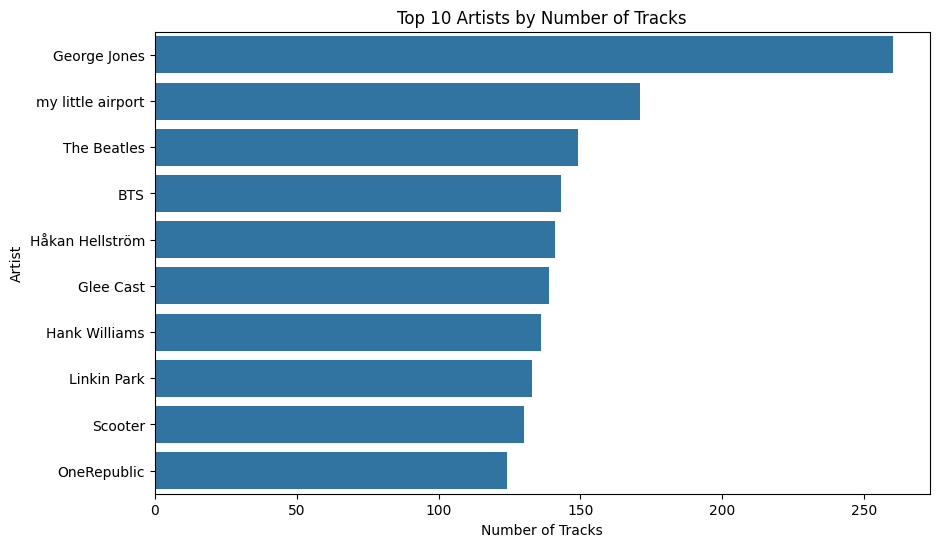

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=artist_track_count.values,
    y=artist_track_count.index
)

plt.title("Top 10 Artists by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")

plt.show()

In [ ]:
artist_popularity = (
    track_level_df.groupby("artists")["popularity"]
    .agg(
        average_popularity="mean",
        track_count="count"
    )
)

In [ ]:
artist_popularity_filtered = (
    artist_popularity[
        artist_popularity["track_count"] >= 5
    ]
    .sort_values("average_popularity", ascending=False)
    .head(10)
)

artist_popularity_filtered

,average_popularity,track_count
artists,,
Olivia Rodrigo,87.400000,5
Bad Bunny,85.363636,22
Lil Nas X,83.200000,5
One Direction,83.000000,5
Måneskin,82.600000,5
Eminem,81.166667,6
Ariana Grande,80.777778,9
Mitski,78.333333,6
Rels B,78.000000,5


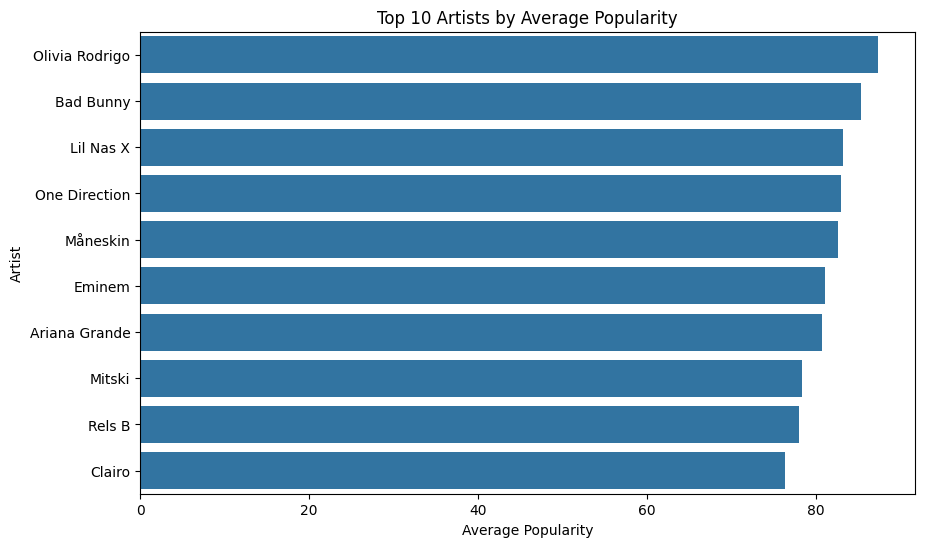

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=artist_popularity_filtered["average_popularity"],
    y=artist_popularity_filtered.index
)

plt.title("Top 10 Artists by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Artist")

plt.show()

**Apakah lagu yang lebih danceable cenderung lebih populer?**

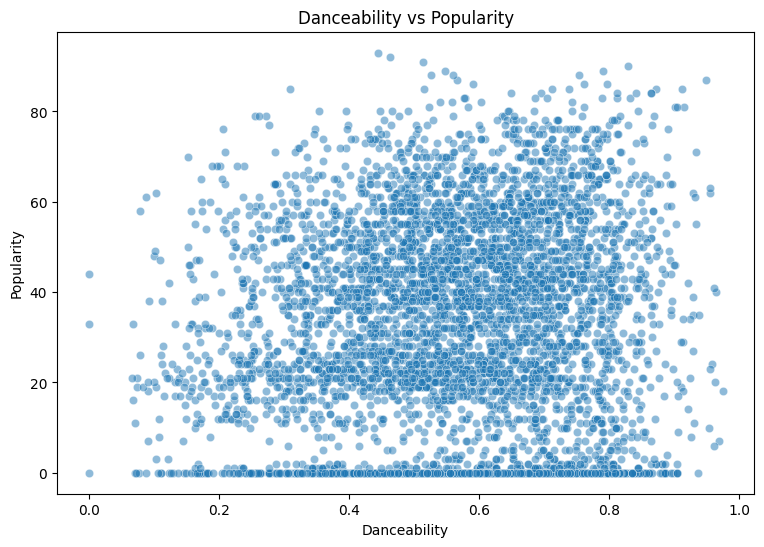

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="danceability",
    y="popularity",
    alpha=0.5
)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

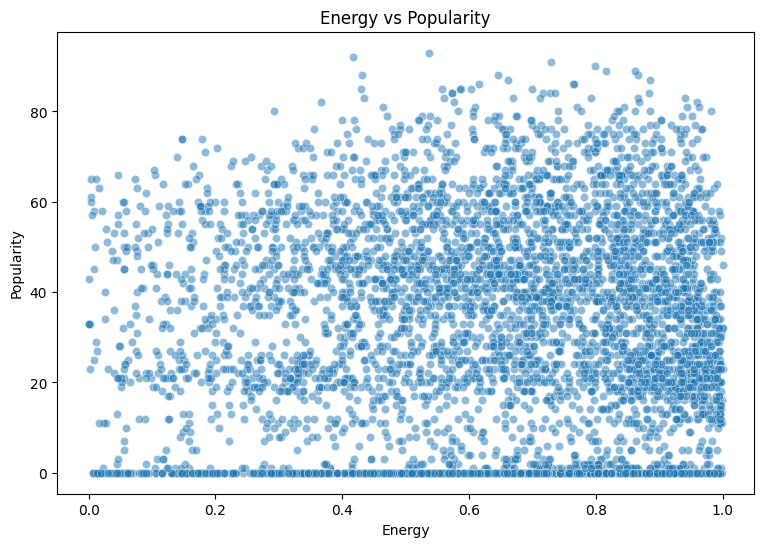

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="energy",
    y="popularity",
    alpha=0.5
)

plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.show()

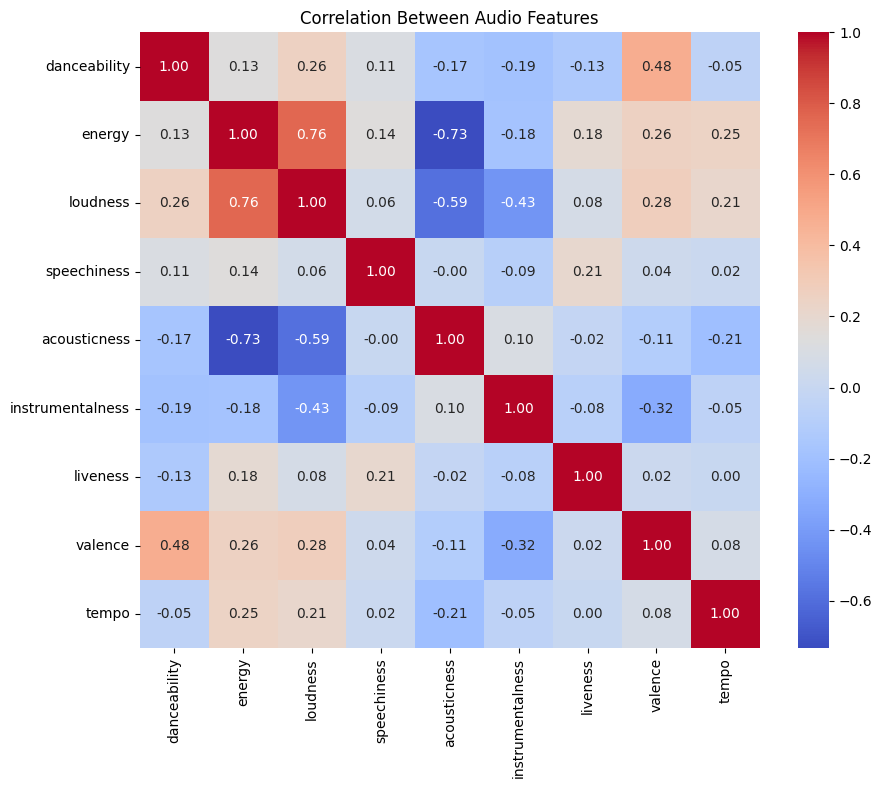

In [ ]:
audio_correlation = df[audio_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    audio_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Audio Features")

plt.show()

## 8. Key Findings

### 1. Popularity Distribution

The average track popularity in the dataset is 33.24, with values ranging from 0 to 100. Most tracks fall into the Low popularity category, while only a relatively small portion of tracks are categorized as High popularity.

### 2. Genre Performance

Pop-film had the highest average popularity among the 114 genres, with an average popularity of approximately 59.28, followed by K-pop with approximately 56.93. This indicates that popularity varies considerably across music genres.

### 3. Top Tracks

The most popular track in the analyzed dataset was "Unholy (feat. Kim Petras)" by Sam Smith and Kim Petras, with a popularity score of 100. Other highly popular tracks included "Quevedo: Bzrp Music Sessions, Vol. 52" and "I'm Good (Blue)".

### 4. Artist Performance

George Jones had the highest number of tracks in the dataset, with 260 tracks. However, having many tracks does not necessarily indicate high average popularity. Among artists with at least five tracks, Olivia Rodrigo had the highest average popularity at approximately 87.40.

### 5. Audio Characteristics

High-popularity tracks showed higher average danceability and energy compared with Low-popularity tracks. High-popularity tracks also had lower average acousticness and instrumentalness.

### 6. Relationship Between Audio Features and Popularity

The correlation analysis showed that individual audio features had very weak linear relationships with popularity. The strongest positive correlation was between loudness and popularity at approximately 0.05, while instrumentalness had the strongest negative correlation at approximately -0.10. Therefore, popularity cannot be strongly explained by a single audio feature in this dataset.

### 7. Relationships Between Audio Features

The correlation analysis among audio features revealed several stronger relationships. Energy and loudness had a strong positive correlation of approximately 0.76, while energy and acousticness had a strong negative correlation of approximately -0.73. These relationships indicate that audio characteristics can be interconnected even though their individual relationships with popularity are weak.

## 9. Conclusion

This analysis explored Spotify tracks based on popularity, genre, artist performance, and audio characteristics.

The analysis found that most tracks in the dataset had relatively low popularity scores, while highly popular tracks represented a smaller proportion of the dataset. Popularity also varied considerably across genres, with pop-film and K-pop among the genres with the highest average popularity.

At the artist level, the number of tracks was not necessarily associated with higher popularity. George Jones had the largest number of tracks, while Olivia Rodrigo achieved the highest average popularity among artists with at least five tracks.

The analysis of audio characteristics showed that high-popularity tracks tended to have higher danceability and energy. However, correlation analysis demonstrated that individual audio features had only very weak linear relationships with popularity. This suggests that song popularity is likely influenced by multiple factors rather than a single audio characteristic.

Overall, the project demonstrates how exploratory data analysis can be used to identify patterns in music data and generate insights from large-scale streaming datasets.

## Project Summary

| Aspect | Result |
|---|---|
| Dataset | Spotify Tracks Dataset |
| Original Records | 114,000 |
| Cleaned Records | 113,999 |
| Unique Tracks | 89,740 |
| Number of Genres | 114 |
| Average Popularity | 33.24 |
| Most Popular Genre | pop-film |
| Most Tracks by Artist | George Jones |
| Highest Average Artist Popularity | Olivia Rodrigo |
| Strongest Audio Correlation | Energy vs Loudness (0.76) |